In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df =pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(9994, 21)
row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date                object
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0

In [8]:
region_sales = df.groupby('region')['sales'].sum().reset_index()
region_sales = region_sales.sort_values('sales', ascending=False)
region_sales

,region,sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


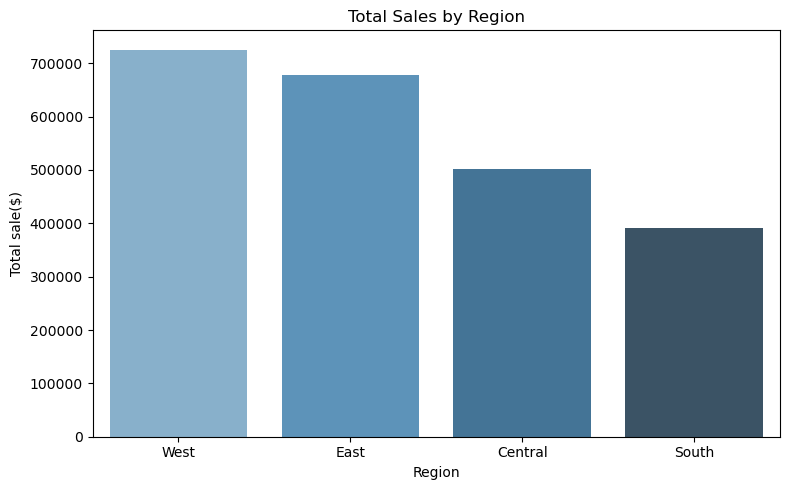

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='region', y='sales',hue='region', palette= 'Blues_d', legend=False)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total sale($)')
plt.tight_layout()
plt.savefig('Sales_by_region.png')
plt.show()

In [10]:
category_sales = df.groupby('category')['sales'].sum().reset_index()
category_sales = category_sales.sort_values('sales', ascending=False)
category_sales

,category,sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


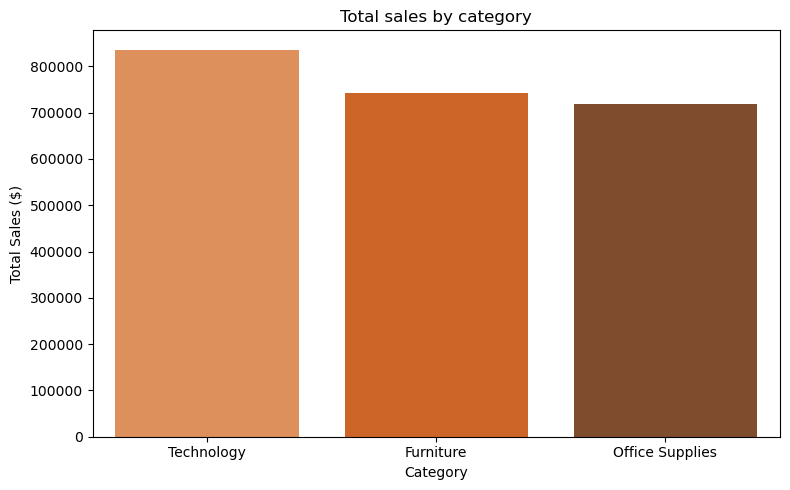

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x= 'category', y='sales', hue= 'category', palette='Oranges_d', legend=False)
plt.title('Total sales by category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

In [13]:
df['month']= df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month')['sales'].sum().reset_index()
monthly_sales['month'] = monthly_sales['month'].astype(str)
monthly_sales

,month,sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


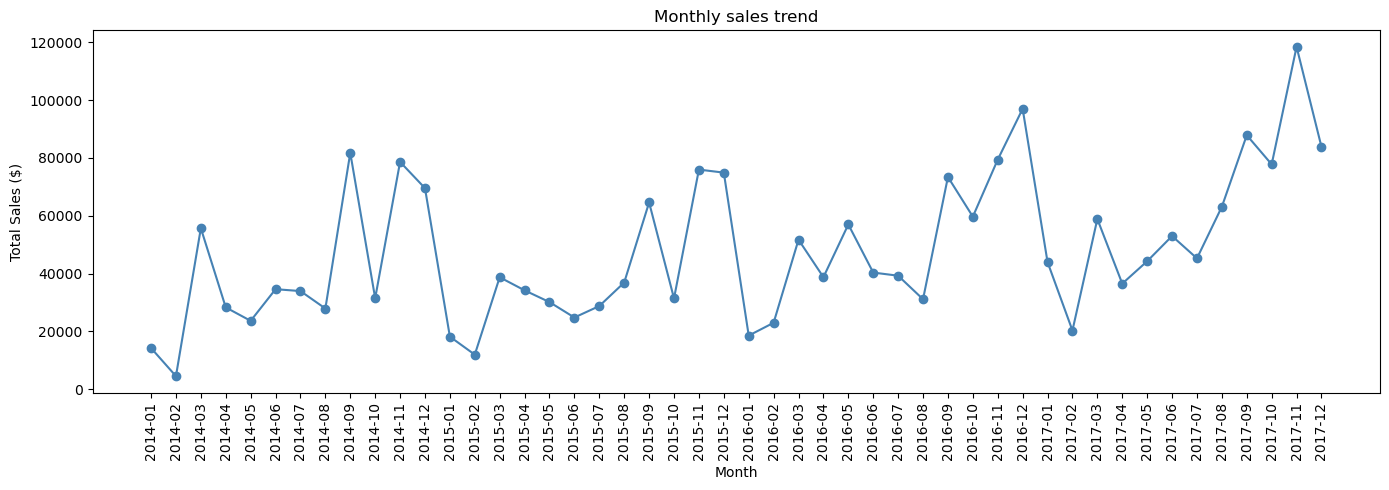

In [14]:
plt.figure(figsize=(14,5))
plt.plot(monthly_sales['month'], monthly_sales['sales'], marker = 'o', color='steelblue')
plt.title('Monthly sales trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

In [15]:
product_sales = df.groupby('product_name')['sales'].sum().reset_index()
product_sales = product_sales.sort_values('sales', ascending=False).head(10)
product_sales

,product_name,sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


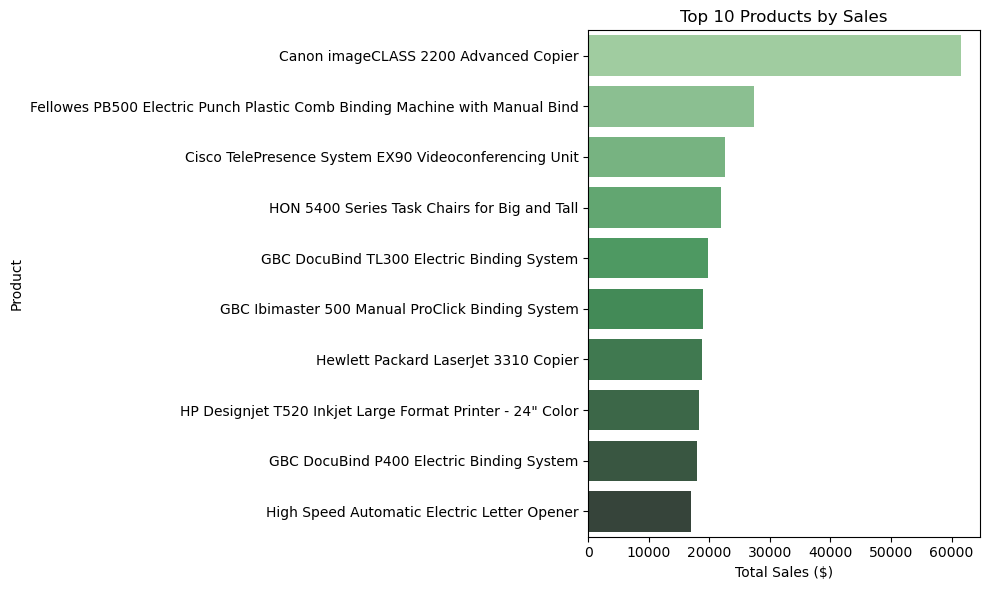

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=product_sales, x='sales', y='product_name',
            hue='product_name', palette='Greens_d', legend=False)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()